# 이미지필터

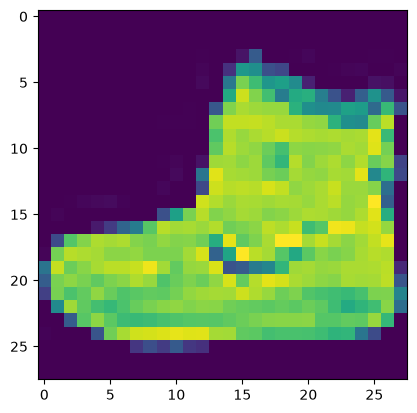

In [10]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# 데이터 받아오기
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 첫번째 데이터 출력하기
plt.imshow(x_train[0])

# 필터 생성

In [11]:
import numpy as np
import cv2

# 가로선을 추출하기 위한 필터
horizontal_filter = np.array([[1., 2., 1.],
                             [0., 0., 0.],
                             [-1., -2., -1.]])

# 세로선을 추출하기 위한 필터
vertical_filter = np.array([[1., 0., -1.],
                           [2., 0., -2.],
                           [1., 0., -1.]])

# 계산의 편의를 위해 이미지의 크기를 (27, 27)로 줄입니다.
test_image = cv2.resize(x_train[0], (27, 27))
image_size = test_image.shape[0]
print(f"감소한 이미지의 크기 : {test_image.shape}")

# Feature Mat: (입력크기 - 필터크기) / stride + 1
output_size = int((image_size - 3)/1 + 1)

print('output의 크기 : %d' % output_size)

감소한 이미지의 크기 : (27, 27)
output의 크기 : 25


# 필터 적용하기

In [12]:
# 필터를 이용해 새로운 이미지 생성(Feature Map)
def get_filtered_image(filter):
    # 출력 이미지에 대한 배열 생성(초기값: 0)
    filtered_image = np.zeros((output_size, output_size))

    # 출력 이미지 크기 만큼 반복
    for i in range(output_size):
        for j in range(output_size):
            # 합성곱 연산(현재 위치의 특징값 추출)
            indice_image = test_image[i:(i + filter_size),
                                      j:(j + filter_size)] * filter

            # 합성곱 결과 계산
            indice_sum = np.sum(indice_image)

            # 픽셀 이미지 범위 제안(0 ~ 255)
            if(indice_sum > 255):
                indice_sum = 255

            # 계산 결과를 출력 이미지(Feature Map)에 저장
            filtered_image[i, j] = indice_sum

    return filtered_image

In [13]:
filter_size = 3

# 세로선 추출 필터 적용
vertical_filtered_image = get_filtered_image(vertical_filter)

# 가로선 추출 필터 적용
horizontal_filtered_image = get_filtered_image(horizontal_filter)


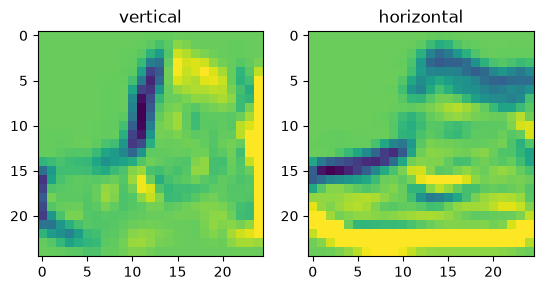

In [14]:
# Feature Map 이미지 비교

plt.subplot(1, 2, 1)
plt.title('vertical')
plt.imshow(vertical_filtered_image)

plt.subplot(1, 2, 2)
plt.title('horizontal')
plt.imshow(horizontal_filtered_image)
plt.show()

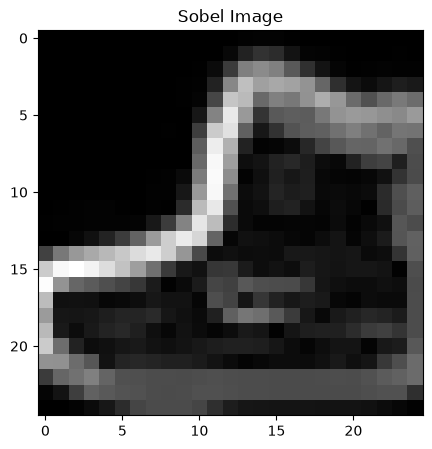

In [18]:
# edge => np.sqrt(Gx^2 + Gy^2)
sobel_image = np.sqrt(np.square(horizontal_filtered_image) +
                      np.square(vertical_filtered_image))

plt.figure(figsize=(10, 5))
plt.title('Sobel Image')
plt.imshow(sobel_image, cmap='gray')